<div style="margin-bottom: 120px;">
    <div style="float:left;">
        <br/>
        <img src="img/udc.png" width="300"/>
    </div>
</div>

<h1 style="color: #d60e8c; text-align:center;">Clasificación con MLP sin balanceo de datos</h1>

<a name="intro"></a>
<h1 style="color: #d60e8c;">Importamos las librerías</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [95]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import time as clocktime

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, ShuffleSplit, KFold, cross_validate, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

<a name="dataset"></a>
<h1 style="color: #d60e8c;">Lectura del conjunto de datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
path = '/content/drive/MyDrive/Notebooks/puntos_pose/puntos_imgs_sin_v.csv'
#path = 'puntos_imgs_sin_v.csv'

In [98]:
df = pd.read_csv(path)
df.head()

,name,front_left_paw_x,front_left_paw_y,front_left_knee_x,front_left_knee_y,front_left_elbow_x,front_left_elbow_y,rear_left_paw_x,rear_left_paw_y,rear_left_knee_x,...,right_ear_tip_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,withers_x,withers_y,throat_x,throat_y,class
0,n02085620_10074.jpg,0.69520,0.96500,0.66066,0.82400,0.66817,0.67700,0.00000,0.00000,0.0,...,0.06820,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,n02085620_10131.jpg,0.00000,0.00000,0.73502,0.90034,0.73165,0.64646,0.00000,0.00000,0.0,...,0.12733,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,n02085620_1073.jpg,0.00000,0.00000,0.58744,0.96600,0.68792,0.77467,0.00000,0.00000,0.0,...,0.05588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,n02085620_10976.jpg,0.69876,0.85744,0.63043,0.80096,0.64286,0.67975,0.69876,0.77376,0.0,...,0.24455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,n02085620_11140.jpg,0.79100,0.56133,0.71000,0.55333,0.62600,0.47867,0.00000,0.00000,0.0,...,0.15180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [28]:
df.shape

(6125, 50)

In [29]:
df['class'].value_counts()

,count
class,
1,3371
0,1454
2,1300


In [30]:
df['class'] = df['class'].map({0: 0, 1: 1, 2: 0})
df['class'].value_counts()

,count
class,
1,3371
0,2754


In [31]:
df['class'].value_counts()

,count
class,
1,3371
0,2754


<a name="division"></a>
<h1 style="color: #d60e8c;">Selección de atributos de entrada y salida</h1>
<hr style="border: 0.5px solid #d60e8c;">


In [34]:
# 30 seleccionadas
feature_df = df[['front_left_paw_x', 'front_left_paw_y', 'front_left_knee_x',
       'front_left_knee_y', 'front_left_elbow_x', 'front_left_elbow_y',
       'rear_left_paw_x', 'rear_left_paw_y', 'rear_left_knee_x',
       'rear_left_knee_y', 'rear_left_elbow_x', 'rear_left_elbow_y',
       'front_right_paw_x', 'front_right_paw_y', 'front_right_knee_x',
       'front_right_knee_y', 'front_right_elbow_x', 'front_right_elbow_y',
       'rear_right_paw_x', 'rear_right_paw_y', 'rear_right_knee_x',
       'rear_right_knee_y', 'rear_right_elbow_x', 'rear_right_elbow_y',
       'tail_start_x', 'tail_start_y', 'withers_x', 'withers_y', 'throat_x', 'throat_y']]
X_orig = np.asarray(feature_df)

In [35]:
y = np.asarray(df[df.columns[len(df.columns)-1]])

<a name="train_test"></a>
<h1 style="color: #d60e8c;">División en datos de entrenamiento y prueba</h1>
<hr style="border: 0.5px solid #d60e8c;">
El siguiente código, utiliza el 80% del conjunto de datos para entrenar el modelo y el 20% para test.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.2, random_state = 4, stratify=y)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (4900, 30) (4900,)
Test set: (1225, 30) (1225,)


<a name="scale"></a>
<h1 style="color: #d60e8c;">Escalado de los datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [37]:
scaler = preprocessing.StandardScaler()
scaler.fit(X_train) # fit realiza los cálculos y los almacena

X_train = scaler.transform(X_train) # aplica los cálculos sobre el conjunto de datos de entrada para escalarlos
X_test = scaler.transform(X_test)

<a name="scale"></a>
<h1 style="color: #d60e8c;">Búsqueda de los mejore hiperparámetros con GridSearchCV</h1>
<hr style="border: 0.5px solid #d60e8c;">


In [ ]:
num_splits = 5

In [38]:
tolerance = 1e-4
iterations = 4000
random_seed = 0

In [41]:
parameters = {'activation': ['relu', 'logistic'],
              'batch_size' : [50, 100, 150],
              'hidden_layer_sizes': [(30,), (60,), (30,30), (30,60),(60,60)]
              }

mlp = MLPClassifier(tol=tolerance, 
                    max_iter=iterations, 
                    random_state=random_seed
                    )

clf = GridSearchCV(mlp, parameters, cv=num_splits, n_jobs=-1, refit=False)
clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=MLPClassifier(max_iter=4000, random_state=0),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'logistic'],
                         'batch_size': [50, 100, 150],
                         'hidden_layer_sizes': [(30,), (60,), (30, 30),
                                                (30, 60), (60, 60)]},
             refit=False)

In [42]:
clf.cv_results_

{'mean_fit_time': array([10.5975527 , 11.94634525, 13.88559405, 13.46840811,  8.9614919 ,
         7.63941391,  7.91964658,  9.80038412,  8.76898535,  7.99519539,
         5.95368385,  7.46298679,  6.99080817,  7.99608056,  6.9513696 ,
        34.23014474, 30.52281276, 19.08606958, 20.12456052, 24.77119819,
        21.62247912, 29.13126445, 16.68752567, 15.56629125, 16.98000105,
        20.98677699, 24.7345318 , 12.81805444, 12.85568531, 10.67333682]),
 'std_fit_time': array([1.48158799, 1.13856007, 0.1896396 , 0.28048437, 0.32850111,
        0.95157744, 0.93206617, 0.7667189 , 1.28742183, 0.39678403,
        1.44074552, 1.31781091, 1.10338069, 1.12673973, 1.1142864 ,
        4.651288  , 5.10023382, 1.3720904 , 3.86611991, 1.73768614,
        2.96740122, 2.63188077, 1.95071658, 1.8115783 , 2.26951475,
        1.38383134, 2.17924246, 1.85443118, 1.661845  , 2.30262462]),
 'mean_score_time': array([0.00213051, 0.00221944, 0.00218836, 0.00263166, 0.00293469,
        0.00148352, 0.00176096

In [43]:
clf.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_activation', 'param_batch_size', 'param_hidden_layer_sizes', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [46]:
import pandas as pd

results_df = pd.DataFrame(clf.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_batch_size,param_hidden_layer_sizes,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
11,7.462987,1.317811,0.002019,0.000235,relu,150,"(60,)","{'activation': 'relu', 'batch_size': 150, 'hid...",0.865361,0.846908,0.856093,0.856121,0.007534,1
5,7.639414,0.951577,0.001484,0.000078,relu,100,"(30,)","{'activation': 'relu', 'batch_size': 100, 'hid...",0.862913,0.845683,0.853031,0.853876,0.007060,2
0,10.597553,1.481588,0.002131,0.000383,relu,50,"(30,)","{'activation': 'relu', 'batch_size': 50, 'hidd...",0.867197,0.844458,0.848745,0.853467,0.009865,3
10,5.953684,1.440746,0.001511,0.000097,relu,150,"(30,)","{'activation': 'relu', 'batch_size': 150, 'hid...",0.869033,0.840784,0.850582,0.853466,0.011712,4
6,7.919647,0.932066,0.001761,0.000084,relu,100,"(60,)","{'activation': 'relu', 'batch_size': 100, 'hid...",0.848225,0.845070,0.860380,0.851225,0.006600,5


In [88]:

best_models = results_df[results_df["rank_test_score"]<=5]
best_models.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_batch_size,param_hidden_layer_sizes,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
11,7.462987,1.317811,0.002019,0.000235,relu,150,"(60,)","{'activation': 'relu', 'batch_size': 150, 'hid...",0.865361,0.846908,0.856093,0.856121,0.007534,1
5,7.639414,0.951577,0.001484,0.000078,relu,100,"(30,)","{'activation': 'relu', 'batch_size': 100, 'hid...",0.862913,0.845683,0.853031,0.853876,0.007060,2
0,10.597553,1.481588,0.002131,0.000383,relu,50,"(30,)","{'activation': 'relu', 'batch_size': 50, 'hidd...",0.867197,0.844458,0.848745,0.853467,0.009865,3
10,5.953684,1.440746,0.001511,0.000097,relu,150,"(30,)","{'activation': 'relu', 'batch_size': 150, 'hid...",0.869033,0.840784,0.850582,0.853466,0.011712,4
6,7.919647,0.932066,0.001761,0.000084,relu,100,"(60,)","{'activation': 'relu', 'batch_size': 100, 'hid...",0.848225,0.845070,0.860380,0.851225,0.006600,5


In [89]:

best_models[["rank_test_score", "mean_test_score", "std_test_score", "params"]]

,rank_test_score,mean_test_score,std_test_score,params
11,1,0.856121,0.007534,"{'activation': 'relu', 'batch_size': 150, 'hid..."
5,2,0.853876,0.007060,"{'activation': 'relu', 'batch_size': 100, 'hid..."
0,3,0.853467,0.009865,"{'activation': 'relu', 'batch_size': 50, 'hidd..."
10,4,0.853466,0.011712,"{'activation': 'relu', 'batch_size': 150, 'hid..."
6,5,0.851225,0.006600,"{'activation': 'relu', 'batch_size': 100, 'hid..."


<a name="crossval"></a>
<h1 style="color: #d60e8c;">Validación cruzada con los mejores modelos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [ ]:
kf_sh = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=0) 

In [91]:
test_sets = []
for train_index, test_index in kf_sh.split(X_train, y_train):
    X_train_split, X_test_split = X_train[train_index], X_train[test_index]
    y_train_split, y_test_split = y_train[train_index], y_train[test_index]
    test_sets.append((X_test_split,y_test_split))

In [92]:

results = {}
for model_conf in best_models["params"]:
    mlp = MLPClassifier(tol=tolerance, 
                    max_iter=iterations, 
                    random_state=random_seed,
                    activation=model_conf['activation'],
                    batch_size=model_conf['batch_size'],
                    hidden_layer_sizes=model_conf['hidden_layer_sizes']                    
                    )
    res_cv_sh = cross_validate(mlp,X_train,y_train,cv=kf_sh, return_estimator=True, n_jobs=-1)

    model_name = f'MLP {model_conf['hidden_layer_sizes']} - batch: {model_conf['batch_size']}, {model_conf['activation']}'
    print(model_name)
    results[model_name] = res_cv_sh


MLP (60,) - batch: 150, relu
MLP (30,) - batch: 100, relu
MLP (30,) - batch: 50, relu
MLP (30,) - batch: 150, relu
MLP (60,) - batch: 100, relu


In [104]:

conf_matrix_list = []
labels = ['0','1'] # En el diccionario las claves de las clases son string


print("\n---------------------------------------------")
print(" Exactitud, precisión y sensibilidad media")
print("---------------------------------------------\n")

print("Modelo                         ", end='')    
print("Exactitud    ", end='')
for label in labels:
    print(f"R({label})      ", end='')
for label in labels:
    print(f"P({label})      ", end='')
    
print("\n-------------------------------------------------------------------------------")

for name, res_cv_sh in results.items():
    estimators = res_cv_sh['estimator']   
    conf_matrix = []
    clf_report = []
    for i in range(len(estimators)):
        estimator = estimators[i]
        # Hacemos la predicción con el estimador del split i sobre el conjunto de test del split i
        y_predict = estimator.predict(test_sets[i][0])
        # Valores esperados del conjunto de test del split i
        y_expected = test_sets[i][1]
        # Obtenemos la matriz de confusión y la añadimos a la lista
        conf_matrix.append(confusion_matrix(y_expected, y_predict))
        # Añadimos el classification_report del estimador actual a la lista
        clf_report.append(classification_report(y_expected, y_predict, output_dict=True, zero_division=1))
        #print(classification_report(y_expected, y_predict))

    conf_matrix_list.append((name,conf_matrix))
    
    recall = np.zeros(len(labels))
    precision = np.zeros(len(labels))
    accuracy = []
    for dic in clf_report:
        # Para cada clase, obtiene su valor de exactitud de cada split y la añade a una lista
        for label in labels:
            recall[labels.index(label)] = recall[labels.index(label)] + dic[label]['recall']
            precision[labels.index(label)] = precision[labels.index(label)] + dic[label]['precision']
        accuracy.append(dic['accuracy']) 
    # Para cada clase, calcula la media de la exactitud
    for label in labels:
        recall[labels.index(label)] = recall[labels.index(label)] / len(clf_report)
        precision[labels.index(label)] = precision[labels.index(label)] / len(clf_report)

    accuracy = np.array(accuracy) # Conversión a nparray para usar la función mean
    mean_acc = accuracy.mean()    


    print(f"{name:28}", end='')        
    print(f"{mean_acc:10.3f}", end='')    
    for label in labels:
        print(f"{recall[labels.index(label)]:10.2}", end='')        
    for label in labels:
        print(f"{precision[labels.index(label)]:10.2}", end='')                   
    print()



---------------------------------------------
 Exactitud, precisión y sensibilidad media
---------------------------------------------

Modelo                         Exactitud    R(0)      R(1)      P(0)      P(1)      
-------------------------------------------------------------------------------
MLP (60,) - batch: 150, relu     0.849      0.84      0.86      0.83      0.87
MLP (30,) - batch: 100, relu     0.848      0.84      0.86      0.83      0.87
MLP (30,) - batch: 50, relu      0.853      0.85      0.86      0.83      0.87
MLP (30,) - batch: 150, relu     0.846      0.83      0.86      0.83      0.86
MLP (60,) - batch: 100, relu     0.845      0.83      0.86      0.83      0.86


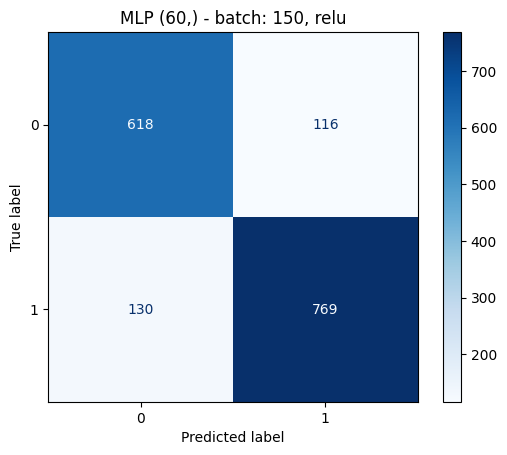

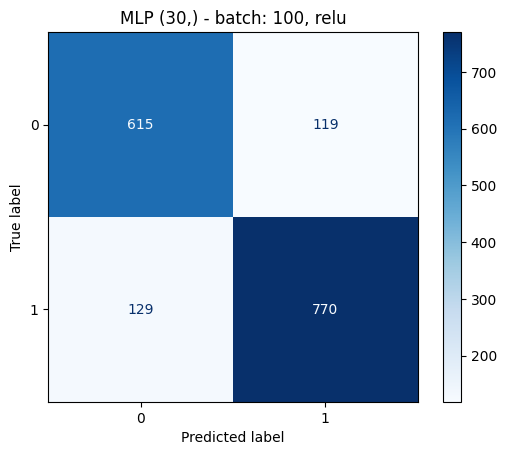

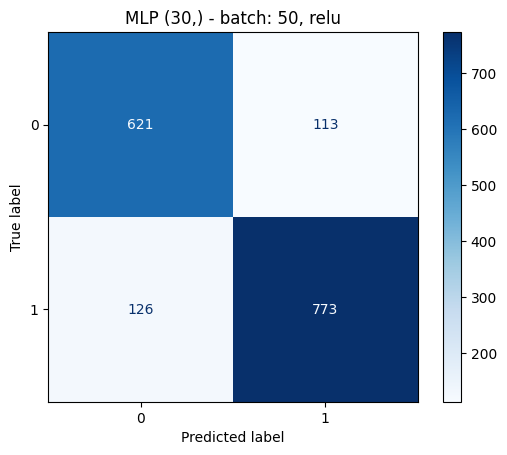

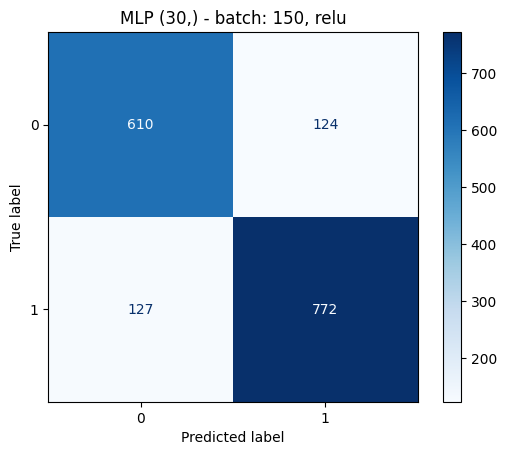

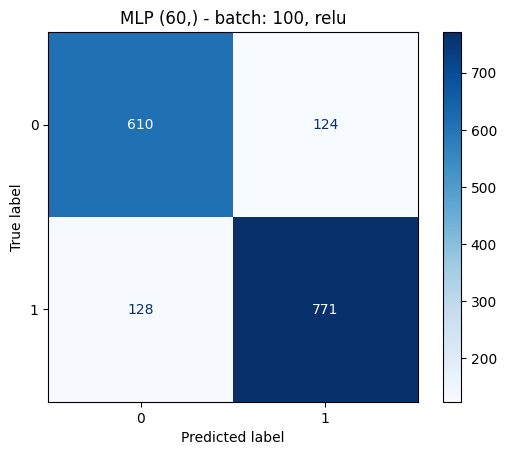

In [121]:

for name, conf_matrix in conf_matrix_list:
    avg_cm = np.zeros(conf_matrix[0].shape, dtype=int)
    for matrix in conf_matrix:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                avg_cm[i,j] +=  matrix[i,j]
    for i in range(avg_cm.shape[0]):
        for j in range(avg_cm.shape[1]):
            avg_cm[i,j] = int(round(avg_cm[i][j]/len(conf_matrix)))    

    disp = ConfusionMatrixDisplay(confusion_matrix=avg_cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(name)    
    plt.savefig(f'matrix_{name}.png',bbox_inches="tight")
    plt.show()
    plt.close()
    

<br/><br/>
<hr style="border: 0.5px solid #d60e8c;">
<div style="text-align:right;">
MASTER UNIVERSITARIO EN INGENIERÍA INDUSTRIAL
</div>